# RGB Benchmark Evaluation Notebook
## Benchmarking LLM Abilities for Retrieval-Augmented Generation

**Paper:** [Benchmarking Large Language Models in Retrieval-Augmented Generation](https://arxiv.org/pdf/2309.01431)
**Dataset:** [RGB GitHub Repository](https://github.com/chen700564/RGB)

---

### What This Notebook Does
RGB tests **4 fundamental LLM abilities** required for reliable RAG systems:

| # | Ability | What It Tests | Metric |
|---|---------|--------------|--------|
| 1 | **Noise Robustness** | Can the LLM extract correct answers despite noisy/irrelevant docs? | Accuracy |
| 2 | **Negative Rejection** | Can the LLM refuse to answer when no relevant doc exists? | Rejection Rate |
| 3 | **Information Integration** | Can the LLM combine info from multiple docs? | Accuracy |
| 4 | **Counterfactual Robustness** | Can the LLM detect & correct factual errors in docs? | Error Detection + Correction Rate |

> **Key difference from RAGBench:** RGB does NOT require you to build a retriever. Documents are pre-provided per question. You only evaluate the LLM's generation quality.

## Step 1: Environment Setup
Install required packages and set up Groq API access.

In [1]:
# Install required packages
!pip install -q groq pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.6 MB/s eta 0:00:00


In [2]:
import json
import os
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq
from tqdm import tqdm
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')

All imports successful!


In [37]:
# ============================================================
# CONFIGURATION - Set your Groq API key here
# ============================================================

from google.colab import userdata, files as colab_files

GROQ_API_KEY = userdata.get('GROQ_API_KEY')

# Initialize Groq client
client = Groq(api_key=GROQ_API_KEY)

# Models to evaluate - add/remove as needed
MODELS_TO_EVALUATE = [
    "llama-3.1-8b-instant",
    "openai/gpt-oss-20b",
    # "llama-3.3-70b-versatile",   # Uncomment if you have quota
    # "deepseek-r1-distill-llama-70b",
]

print(f'Groq client initialized. Will evaluate {len(MODELS_TO_EVALUATE)} models.')

Groq client initialized. Will evaluate 2 models.


## Step 2: Download the RGB Dataset
The RGB dataset lives on GitHub (NOT HuggingFace). It has 3 JSON files for English:
- `en.json` → Noise Robustness (300 questions) + Negative Rejection (uses same questions but with all-negative docs)
- `en_int.json` → Information Integration (100 questions requiring multi-doc reasoning)
- `en_fact.json` → Counterfactual Robustness (100 questions with deliberately wrong facts in docs)

In [12]:
# Download RGB dataset from GitHub
import urllib.request

os.makedirs('rgb_data', exist_ok=True)

# RGB dataset URLs from the official repo
RGB_FILES = {
    'en': 'https://raw.githubusercontent.com/chen700564/RGB/refs/heads/master/data/en.json',
    'en_int': 'https://raw.githubusercontent.com/chen700564/RGB/refs/heads/master/data/en_int.json',
    'en_fact': 'https://raw.githubusercontent.com/chen700564/RGB/refs/heads/master/data/en_fact.json',
}

for name, url in RGB_FILES.items():
    filepath = f'rgb_data/{name}.json'
    if not os.path.exists(filepath):
        print(f'Downloading {name}.json ...')
        try:
            urllib.request.urlretrieve(url, filepath)
            print(f'  ✅ Saved to {filepath}')
        except Exception as e:
            print(f'  ❌ Error downloading {name}: {e}')
            print(f'  💡 Manually download from: {url}')
    else:
        print(f'  ✅ {filepath} already exists')

print('\nDone! Check rgb_data/ folder.')

  ✅ Saved to rgb_data/en.json
  ✅ Saved to rgb_data/en_int.json
  ✅ Saved to rgb_data/en_fact.json

Done! Check rgb_data/ folder.


## Step 3: Load & Explore the Dataset
Understand the structure of each JSON file before writing evaluation code.

In [14]:
import os
files = ["rgb_data/en.json", "rgb_data/en_int.json", "rgb_data/en_fact.json"]
for f in files:
    size = os.path.getsize(f) if os.path.exists(f) else "MISSING"
    if os.path.exists(f):
        with open(f, 'rb') as fh:
            preview = fh.read(200)
        print(f"📄 {f} | size: {size} bytes")
        print(f"   Preview: {preview[:200]}\n")
    else:
        print(f"❌ {f} MISSING\n")

📄 rgb_data/en.json | size: 10808210 bytes
   Preview: b'{"id": 0, "query": "When is the premiere of \'Carole King & James Taylor: Just Call Out My Name\'?", "answer": [["January 2 2022", "Jan 2, 2022", "Jan. 2, 2022", "January 2, 2022", "2 January 2022", "2 '

📄 rgb_data/en_int.json | size: 5138444 bytes
   Preview: b'{"id": 0, "query": "Who is the director of \'Carole King & James Taylor: Just Call Out My Name\' and when is its premiere?", "answer": [["January 2 2022", "Jan 2, 2022", "Jan. 2, 2022", "January 2, 2022'

📄 rgb_data/en_fact.json | size: 241320 bytes
   Preview: b'{"id": 0, "query": "Super Bowl 2021 location", "answer": "Tampa, Florida", "fakeanswer": "Glendale, Arizona", "positive_wrong": ["The game was played on February 7, 2021, at Raymond James Stadium in G'



In [15]:
# Load all three datasets
def load_rgb_data(filepath):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                data.append(json.loads(line))
    return data

data_en = load_rgb_data('rgb_data/en.json')
data_int = load_rgb_data('rgb_data/en_int.json')
data_fact = load_rgb_data('rgb_data/en_fact.json')

print(f'en.json      : {len(data_en)} questions  (Noise Robustness + Negative Rejection)')
print(f'en_int.json  : {len(data_int)} questions  (Information Integration)')
print(f'en_fact.json : {len(data_fact)} questions  (Counterfactual Robustness)')
print(f'\nTotal English questions: {len(data_en) + len(data_int) + len(data_fact)}')

en.json      : 300 questions  (Noise Robustness + Negative Rejection)
en_int.json  : 100 questions  (Information Integration)
en_fact.json : 100 questions  (Counterfactual Robustness)

Total English questions: 500


In [16]:
# Explore the structure of one sample from each dataset
print('=' * 60)
print('SAMPLE FROM en.json (Noise Robustness / Negative Rejection)')
print('=' * 60)
sample = data_en[0]
print(f'Keys: {list(sample.keys())}')
print(f'\nQuestion: {sample.get("question", sample.get("query", "N/A"))[:200]}')
print(f'Answer: {sample.get("answer", "N/A")[:200]}')

# Check document structure
docs_key = None
for k in ['documents', 'passages', 'context', 'docs']:
    if k in sample:
        docs_key = k
        break
if docs_key:
    print(f'\nDocuments key: "{docs_key}"')
    print(f'Number of documents: {len(sample[docs_key])}')
    if isinstance(sample[docs_key][0], dict):
        print(f'Document keys: {list(sample[docs_key][0].keys())}')
    print(f'First doc preview: {str(sample[docs_key][0])[:300]}')
else:
    print(f'\n⚠️ No documents key found. Available keys: {list(sample.keys())}')
    # Print all keys and their types for debugging
    for k, v in sample.items():
        print(f'  {k}: {type(v).__name__} = {str(v)[:150]}')

print('\n' + '=' * 60)
print('SAMPLE FROM en_int.json (Information Integration)')
print('=' * 60)
sample_int = data_int[0]
for k, v in sample_int.items():
    print(f'  {k}: {type(v).__name__} = {str(v)[:200]}')

print('\n' + '=' * 60)
print('SAMPLE FROM en_fact.json (Counterfactual Robustness)')
print('=' * 60)
sample_fact = data_fact[0]
for k, v in sample_fact.items():
    print(f'  {k}: {type(v).__name__} = {str(v)[:200]}')

SAMPLE FROM en.json (Noise Robustness / Negative Rejection)
Keys: ['id', 'query', 'answer', 'positive', 'negative']

Question: When is the premiere of 'Carole King & James Taylor: Just Call Out My Name'?
Answer: [['January 2 2022', 'Jan 2, 2022', 'Jan. 2, 2022', 'January 2, 2022', '2 January 2022', '2 Jan, 2022', '2 Jan., 2022', '2 January, 2022']]

⚠️ No documents key found. Available keys: ['id', 'query', 'answer', 'positive', 'negative']
  id: int = 0
  query: str = When is the premiere of 'Carole King & James Taylor: Just Call Out My Name'?
  answer: list = [['January 2 2022', 'Jan 2, 2022', 'Jan. 2, 2022', 'January 2, 2022', '2 January 2022', '2 Jan, 2022', '2 Jan., 2022', '2 January, 2022']]
  positive: list = ['However, the concert tour took place in honor of the 40th anniversary. The two might have aged since they first performed together but neither Carol
  negative: list = ['By   \tAlthea Legaspi  Carole King and James Taylor perform their own hits — alongside harmonizing on 

## Step 4: Define Helper Functions
### 4a. LLM Call Wrapper with Rate-Limit Handling
Groq has rate limits — we need retry logic with exponential backoff.

In [24]:
def call_llm(model_name, system_prompt, user_prompt, max_retries=5, temperature=0.1):
    """
    Call Groq LLM with retry logic for rate limits.
    Returns the generated text or None on failure.
    """
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model_name,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
                temperature=temperature,
                max_tokens=1024,
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            error_str = str(e)
            if 'rate_limit' in error_str.lower() or '429' in error_str:
                wait_time = 2 ** attempt * 10  # 10, 20, 40, 80, 160 seconds
                print(f'    ⏳ Rate limited. Waiting {wait_time}s (attempt {attempt+1}/{max_retries})')
                time.sleep(wait_time)
            else:
                print(f'    ❌ Error: {error_str[:200]}')
                return None
    print(f'    ❌ Max retries exceeded for model {model_name}')
    return None

# Quick test
test_resp = call_llm(MODELS_TO_EVALUATE[0], 'You are helpful.', 'Say hello in 5 words.')
print(f'Test response: {test_resp}')

Test response: Hello, how are you today?


### 4b. Prompt Templates for Each RGB Ability
Each ability needs a specific prompt structure. These follow the RGB paper's approach.

In [25]:
# ============================================================
# PROMPT TEMPLATES — Based on RGB paper Section 3
# ============================================================

def build_document_context(documents):
    """
    Build a formatted context string from the list of documents.
    Handles both string lists and dict lists.
    """
    context_parts = []
    for i, doc in enumerate(documents, 1):
        if isinstance(doc, dict):
            text = doc.get('text', doc.get('content', doc.get('passage', str(doc))))
        else:
            text = str(doc)
        context_parts.append(f'Document [{i}]: {text}')
    return '\n\n'.join(context_parts)


# --- Noise Robustness & Information Integration ---
SYSTEM_PROMPT_ACCURACY = """You are a helpful assistant. Answer the question based on the given documents.
Provide a concise and direct answer. If the answer involves a specific name, date, number, or entity, state it clearly."""

USER_PROMPT_ACCURACY = """Given the following documents, answer the question.

{context}

Question: {question}

Answer:"""


# --- Negative Rejection ---
SYSTEM_PROMPT_REJECTION = """You are a helpful assistant. Answer the question based ONLY on the given documents.
If the provided documents do not contain sufficient information to answer the question,
you MUST respond with exactly: "I can not answer the question because of insufficient information in documents."
Do not guess or make up an answer."""

USER_PROMPT_REJECTION = """Given the following documents, answer the question.
If the documents do not contain enough information, respond with:
"I can not answer the question because of insufficient information in documents."

{context}

Question: {question}

Answer:"""


# --- Counterfactual Robustness ---
SYSTEM_PROMPT_COUNTERFACTUAL = """You are a helpful assistant. Answer the question based on the given documents.
IMPORTANT: Some documents may contain factual errors or incorrect information.
If you detect factual errors in any document, first state:
"There are factual errors in the provided documents."
Then provide the correct answer based on your knowledge."""

USER_PROMPT_COUNTERFACTUAL = """Given the following documents, answer the question.
WARNING: Some documents may contain factual errors.
If you find factual errors, first say "There are factual errors in the provided documents."
Then give the correct answer.

{context}

Question: {question}

Answer:"""

print('✅ All prompt templates defined.')

✅ All prompt templates defined.


### 4c. Data Extraction Helpers
Extract questions, documents, and answers from the RGB JSON structure.
**Run the exploration cell above first** to verify the exact key names, then adjust if needed.

In [26]:
def extract_question(item):
    """Extract question text from an RGB data item."""
    for key in ['question', 'query', 'input']:
        if key in item:
            return item[key]
    return None

def extract_answer(item):
    """Extract ground truth answer from an RGB data item."""
    for key in ['answer', 'answers', 'gold_answer', 'target']:
        if key in item:
            val = item[key]
            if isinstance(val, list):
                return val  # Some questions have multiple valid answers
            return [val]
    return []

def extract_documents(item):
    """Extract document list from an RGB data item."""
    for key in ['documents', 'passages', 'context', 'docs', 'positive_passages', 'negative_passages']:
        if key in item and isinstance(item[key], list):
            return item[key]
    # Fallback: check if there are numbered document keys
    docs = []
    for k in sorted(item.keys()):
        if k.startswith('doc') or k.startswith('passage'):
            docs.append(item[k])
    return docs if docs else []

def extract_negative_documents(item):
    """
    For Negative Rejection: get only the negative (irrelevant) documents.
    In RGB, negative rejection uses all docs as noise — none contain the answer.
    """
    # First check if there's a specific negative docs field
    for key in ['negative_passages', 'noise_passages', 'negative_documents']:
        if key in item and isinstance(item[key], list):
            return item[key]
    # Fallback: for negative rejection, the en.json items with all noise docs
    return extract_documents(item)

# Quick validation
sample = data_en[0]
print(f'Question: {extract_question(sample)[:100]}...')
print(f'Answer: {extract_answer(sample)}')
print(f'Num docs: {len(extract_documents(sample))}')

Question: When is the premiere of 'Carole King & James Taylor: Just Call Out My Name'?...
Answer: [['January 2 2022', 'Jan 2, 2022', 'Jan. 2, 2022', 'January 2, 2022', '2 January 2022', '2 Jan, 2022', '2 Jan., 2022', '2 January, 2022']]
Num docs: 0


### 4d. Evaluation Metric Functions
Each ability has its own metric:
- **Noise Robustness → Accuracy** (exact match: does response contain the GT answer?)
- **Negative Rejection → Rejection Rate** (did the LLM output the rejection phrase?)
- **Information Integration → Accuracy** (same exact match)
- **Counterfactual Robustness → Error Detection Rate + Error Correction Rate**

In [27]:
def check_accuracy(response, ground_truth_answers):
    """
    Accuracy check for Noise Robustness and Information Integration.
    Uses exact matching: if the generated text contains the ground truth answer,
    it is considered correct. (Per RGB paper Section 3.2)

    Args:
        response: LLM generated text
        ground_truth_answers: list of acceptable answers
    Returns:
        1 if correct, 0 if incorrect
    """
    if response is None:
        return 0
    response_lower = response.lower().strip()
    for ans in ground_truth_answers:
        if isinstance(ans, list):
            # Handle nested answer lists
            for a in ans:
                if str(a).lower().strip() in response_lower:
                    return 1
        else:
            if str(ans).lower().strip() in response_lower:
                return 1
    return 0


def check_rejection(response):
    """
    Rejection check for Negative Rejection.
    The LLM should output a phrase indicating it cannot answer.
    (Per RGB paper: "I can not answer the question because of insufficient information")

    Returns:
        1 if rejected (good), 0 if it attempted to answer (bad)
    """
    if response is None:
        return 0
    response_lower = response.lower()
    rejection_phrases = [
        'i can not answer',
        'i cannot answer',
        'cannot be answered',
        'insufficient information',
        'not enough information',
        'no relevant information',
        'unable to answer',
        'do not have enough',
        'don\'t have enough',
        'no information available',
        'documents do not contain',
        'documents don\'t contain',
        'not mentioned in',
        'no answer can be found',
    ]
    return 1 if any(phrase in response_lower for phrase in rejection_phrases) else 0


def check_error_detection(response):
    """
    Error Detection check for Counterfactual Robustness.
    The LLM should flag that documents contain factual errors.

    Returns:
        1 if error detected, 0 otherwise
    """
    if response is None:
        return 0
    response_lower = response.lower()
    detection_phrases = [
        'factual error',
        'factually incorrect',
        'incorrect information',
        'inaccurate information',
        'error in the',
        'errors in the',
        'not accurate',
        'is incorrect',
        'are incorrect',
        'contains an error',
        'contain errors',
        'factual inaccuracy',
        'misinformation',
        'wrong information',
    ]
    return 1 if any(phrase in response_lower for phrase in detection_phrases) else 0


def check_error_correction(response, ground_truth_answers):
    """
    Error Correction check for Counterfactual Robustness.
    After detecting the error, the LLM should still provide the CORRECT answer.

    Returns:
        1 if correct answer given despite error, 0 otherwise
    """
    return check_accuracy(response, ground_truth_answers)


print('✅ All metric functions defined.')
print()
# Quick tests
print('Test accuracy:', check_accuracy('The answer is Paris', ['Paris']))  # Should be 1
print('Test rejection:', check_rejection('I cannot answer the question'))  # Should be 1
print('Test detection:', check_error_detection('There are factual errors in the documents'))  # Should be 1

✅ All metric functions defined.

Test accuracy: 1
Test rejection: 1
Test detection: 1


## Step 5: Core Evaluation Functions
One function per ability. Each loops through the dataset, calls the LLM, and computes the metric.

In [28]:
def evaluate_noise_robustness(model_name, data, max_samples=None, delay=1.5):
    """
    Evaluate Noise Robustness: Can the LLM answer correctly with noisy docs?
    Uses ALL documents (including noise) from en.json.
    """
    results = []
    samples = data[:max_samples] if max_samples else data

    print(f'\n📊 Noise Robustness — {model_name} — {len(samples)} samples')
    for i, item in enumerate(tqdm(samples, desc='Noise Robustness')):
        question = extract_question(item)
        gt_answers = extract_answer(item)
        documents = extract_documents(item)

        if not question or not gt_answers:
            continue

        context = build_document_context(documents)
        user_prompt = USER_PROMPT_ACCURACY.format(context=context, question=question)

        response = call_llm(model_name, SYSTEM_PROMPT_ACCURACY, user_prompt)
        correct = check_accuracy(response, gt_answers)

        results.append({
            'index': i,
            'question': question[:100],
            'gt_answer': str(gt_answers),
            'response': response[:300] if response else 'FAILED',
            'correct': correct,
        })
        time.sleep(delay)  # Respect rate limits

    accuracy = sum(r['correct'] for r in results) / len(results) if results else 0
    print(f'  ✅ Accuracy: {accuracy:.4f} ({sum(r["correct"] for r in results)}/{len(results)})')
    return results, accuracy

print('✅ evaluate_noise_robustness defined')

✅ evaluate_noise_robustness defined


In [29]:
def evaluate_negative_rejection(model_name, data, max_samples=None, delay=1.5):
    """
    Evaluate Negative Rejection: Can the LLM refuse when docs are all irrelevant?

    Per RGB paper: Negative Rejection samples are created from the Noise Robustness
    testbed by using ONLY the negative (irrelevant) documents. The LLM should refuse.

    If the dataset doesn't have separate negative docs, we skip positive docs
    and only pass noise documents to the LLM.
    """
    results = []
    samples = data[:max_samples] if max_samples else data

    print(f'\n🚫 Negative Rejection — {model_name} — {len(samples)} samples')
    for i, item in enumerate(tqdm(samples, desc='Negative Rejection')):
        question = extract_question(item)
        gt_answers = extract_answer(item)

        # Get negative documents only
        # Strategy: use negative_passages if available, otherwise use all docs
        # but filter out the ones that contain the answer
        all_docs = extract_documents(item)
        neg_docs = []
        for doc in all_docs:
            doc_text = doc.get('text', str(doc)) if isinstance(doc, dict) else str(doc)
            # Check if this doc contains the answer
            contains_answer = False
            for ans in gt_answers:
                if str(ans).lower() in doc_text.lower():
                    contains_answer = True
                    break
            if not contains_answer:
                neg_docs.append(doc)

        # If no negative docs found, skip this sample
        if not neg_docs:
            continue

        context = build_document_context(neg_docs)
        user_prompt = USER_PROMPT_REJECTION.format(context=context, question=question)

        response = call_llm(model_name, SYSTEM_PROMPT_REJECTION, user_prompt)
        rejected = check_rejection(response)

        results.append({
            'index': i,
            'question': question[:100],
            'response': response[:300] if response else 'FAILED',
            'rejected': rejected,
        })
        time.sleep(delay)

    rejection_rate = sum(r['rejected'] for r in results) / len(results) if results else 0
    print(f'  ✅ Rejection Rate: {rejection_rate:.4f} ({sum(r["rejected"] for r in results)}/{len(results)})')
    return results, rejection_rate

print('✅ evaluate_negative_rejection defined')

✅ evaluate_negative_rejection defined


In [30]:
def evaluate_information_integration(model_name, data, max_samples=None, delay=1.5):
    """
    Evaluate Information Integration: Can the LLM combine info from multiple docs?
    Uses en_int.json — questions that require synthesizing multiple documents.
    """
    results = []
    samples = data[:max_samples] if max_samples else data

    print(f'\n🔗 Information Integration — {model_name} — {len(samples)} samples')
    for i, item in enumerate(tqdm(samples, desc='Info Integration')):
        question = extract_question(item)
        gt_answers = extract_answer(item)
        documents = extract_documents(item)

        if not question or not gt_answers:
            continue

        context = build_document_context(documents)
        user_prompt = USER_PROMPT_ACCURACY.format(context=context, question=question)

        response = call_llm(model_name, SYSTEM_PROMPT_ACCURACY, user_prompt)
        correct = check_accuracy(response, gt_answers)

        results.append({
            'index': i,
            'question': question[:100],
            'gt_answer': str(gt_answers),
            'response': response[:300] if response else 'FAILED',
            'correct': correct,
        })
        time.sleep(delay)

    accuracy = sum(r['correct'] for r in results) / len(results) if results else 0
    print(f'  ✅ Accuracy: {accuracy:.4f} ({sum(r["correct"] for r in results)}/{len(results)})')
    return results, accuracy

print('✅ evaluate_information_integration defined')

✅ evaluate_information_integration defined


In [31]:
def evaluate_counterfactual_robustness(model_name, data, max_samples=None, delay=1.5):
    """
    Evaluate Counterfactual Robustness: Can the LLM detect and correct factual errors?
    Uses en_fact.json — documents deliberately contain wrong facts.

    Returns TWO metrics:
      - Error Detection Rate: Did the LLM flag the error?
      - Error Correction Rate: Did the LLM still give the correct answer?
    """
    results = []
    samples = data[:max_samples] if max_samples else data

    print(f'\n🔍 Counterfactual Robustness — {model_name} — {len(samples)} samples')
    for i, item in enumerate(tqdm(samples, desc='Counterfactual')):
        question = extract_question(item)
        gt_answers = extract_answer(item)
        documents = extract_documents(item)

        if not question or not gt_answers:
            continue

        context = build_document_context(documents)
        user_prompt = USER_PROMPT_COUNTERFACTUAL.format(context=context, question=question)

        response = call_llm(model_name, SYSTEM_PROMPT_COUNTERFACTUAL, user_prompt)
        detected = check_error_detection(response)
        corrected = check_error_correction(response, gt_answers)

        results.append({
            'index': i,
            'question': question[:100],
            'gt_answer': str(gt_answers),
            'response': response[:300] if response else 'FAILED',
            'error_detected': detected,
            'error_corrected': corrected,
        })
        time.sleep(delay)

    detection_rate = sum(r['error_detected'] for r in results) / len(results) if results else 0
    correction_rate = sum(r['error_corrected'] for r in results) / len(results) if results else 0
    print(f'  ✅ Error Detection Rate:  {detection_rate:.4f} ({sum(r["error_detected"] for r in results)}/{len(results)})')
    print(f'  ✅ Error Correction Rate: {correction_rate:.4f} ({sum(r["error_corrected"] for r in results)}/{len(results)})')
    return results, detection_rate, correction_rate

print('✅ evaluate_counterfactual_robustness defined')

✅ evaluate_counterfactual_robustness defined


## Step 6: Run the Full Evaluation
### 6a. Configuration
Set how many samples to evaluate per ability. Start small (20-30) to test, then scale up.

In [38]:
# ============================================================
# EVALUATION CONFIGURATION
# ============================================================
# Start small (20-30) to test. Increase to None for full dataset.
MAX_SAMPLES_PER_ABILITY = 30   # Set to None for full evaluation
DELAY_BETWEEN_CALLS = 2.0       # Seconds between API calls (increase if rate limited)

print(f'Will evaluate {MAX_SAMPLES_PER_ABILITY or "ALL"} samples per ability')
print(f'Models to evaluate: {MODELS_TO_EVALUATE}')
print(f'Delay between calls: {DELAY_BETWEEN_CALLS}s')
print(f'\nEstimated time per model (30 samples × 4 abilities × {DELAY_BETWEEN_CALLS}s): ~{30 * 4 * DELAY_BETWEEN_CALLS / 60:.0f} min')

Will evaluate 30 samples per ability
Models to evaluate: ['llama-3.1-8b-instant', 'openai/gpt-oss-20b']
Delay between calls: 2.0s

Estimated time per model (30 samples × 4 abilities × 2.0s): ~4 min


### 6b. Run Evaluation for All Models
This is the main execution cell. It will loop through each model and all 4 abilities.

In [36]:
import requests
import os

GROQ_API_KEY = userdata.get('GROQ_API_KEY')
url = "https://api.groq.com/openai/v1/models"

headers = {
    "Authorization": f"Bearer {GROQ_API_KEY}",
    "Content-Type": "application/json"
}

response = requests.get(url, headers=headers)

print(response.json())

{'object': 'list', 'data': [{'id': 'groq/compound-mini', 'object': 'model', 'created': 1756949707, 'owned_by': 'Groq', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 8192, 'hugging_face_id': 'groq/compound-beta-mini', 'name': 'Compound Mini', 'input_modalities': ['text'], 'output_modalities': ['text'], 'context_length': 131072, 'max_output_length': 8192, 'supported_sampling_parameters': ['temperature', 'top_p', 'stop', 'seed', 'max_tokens'], 'supported_features': ['json_mode']}, {'id': 'whisper-large-v3', 'object': 'model', 'created': 1693721698, 'owned_by': 'OpenAI', 'active': True, 'context_window': 448, 'public_apps': None, 'max_completion_tokens': 448, 'hugging_face_id': 'openai/whisper-large-v3', 'name': 'Whisper', 'input_modalities': ['audio'], 'output_modalities': ['transcription'], 'context_length': 448, 'max_output_length': 448}, {'id': 'openai/gpt-oss-20b', 'object': 'model', 'created': 1754407957, 'owned_by': 'OpenAI', 'active': True,

In [39]:
# ============================================================
# MAIN EVALUATION LOOP
# ============================================================
all_results = {}  # model_name -> {ability -> results}
summary_rows = []

for model_name in MODELS_TO_EVALUATE:
    print(f'\n{"="*60}')
    print(f'EVALUATING MODEL: {model_name}')
    print(f'{"="*60}')

    model_results = {}

    # 1. Noise Robustness (en.json)
    nr_results, nr_accuracy = evaluate_noise_robustness(
        model_name, data_en, MAX_SAMPLES_PER_ABILITY, DELAY_BETWEEN_CALLS
    )
    model_results['noise_robustness'] = nr_results

    # 2. Negative Rejection (en.json, negative docs only)
    rej_results, rej_rate = evaluate_negative_rejection(
        model_name, data_en, MAX_SAMPLES_PER_ABILITY, DELAY_BETWEEN_CALLS
    )
    model_results['negative_rejection'] = rej_results

    # 3. Information Integration (en_int.json)
    ii_results, ii_accuracy = evaluate_information_integration(
        model_name, data_int, MAX_SAMPLES_PER_ABILITY, DELAY_BETWEEN_CALLS
    )
    model_results['information_integration'] = ii_results

    # 4. Counterfactual Robustness (en_fact.json)
    cf_results, cf_detection, cf_correction = evaluate_counterfactual_robustness(
        model_name, data_fact, MAX_SAMPLES_PER_ABILITY, DELAY_BETWEEN_CALLS
    )
    model_results['counterfactual_robustness'] = cf_results

    all_results[model_name] = model_results

    # Collect summary
    summary_rows.append({
        'Model': model_name,
        'Noise Robustness (Accuracy)': f'{nr_accuracy:.4f}',
        'Negative Rejection (Rate)': f'{rej_rate:.4f}',
        'Info Integration (Accuracy)': f'{ii_accuracy:.4f}',
        'Counterfactual Detection': f'{cf_detection:.4f}',
        'Counterfactual Correction': f'{cf_correction:.4f}',
    })

print(f'\n{"="*60}')
print('ALL EVALUATIONS COMPLETE!')
print(f'{"="*60}')


EVALUATING MODEL: llama-3.1-8b-instant

📊 Noise Robustness — llama-3.1-8b-instant — 30 samples


Noise Robustness: 100%|██████████| 30/30 [01:08<00:00,  2.28s/it]


  ✅ Accuracy: 0.2667 (8/30)

🚫 Negative Rejection — llama-3.1-8b-instant — 30 samples


Negative Rejection: 100%|██████████| 30/30 [00:00<00:00, 149796.57it/s]


  ✅ Rejection Rate: 0.0000 (0/0)

🔗 Information Integration — llama-3.1-8b-instant — 30 samples


...

  ✅ Rejection Rate: 0.0000 (0/0)

🔗 Information Integration — openai/gpt-oss-20b — 30 samples


Info Integration: 100%|██████████| 30/30 [02:38<00:00,  5.27s/it]


  ✅ Accuracy: 0.2333 (7/30)

🔍 Counterfactual Robustness — openai/gpt-oss-20b — 30 samples


Counterfactual: 100%|██████████| 30/30 [01:55<00:00,  3.86s/it]

  ✅ Error Detection Rate:  0.0000 (0/30)
  ✅ Error Correction Rate: 0.2667 (8/30)

ALL EVALUATIONS COMPLETE!


## Step 7: Results Summary & Visualization
### 7a. Summary Table

In [40]:
# Display summary table
df_summary = pd.DataFrame(summary_rows)
print('\n📊 RGB BENCHMARK RESULTS SUMMARY')
print('=' * 80)
display(df_summary)

# Save to CSV
df_summary.to_csv('rgb_results_summary.csv', index=False)
print('\n✅ Results saved to rgb_results_summary.csv')


📊 RGB BENCHMARK RESULTS SUMMARY


,Model,Noise Robustness (Accuracy),Negative Rejection (Rate),Info Integration (Accuracy),Counterfactual Detection,Counterfactual Correction
0,llama-3.1-8b-instant,0.2667,0.0000,0.7000,0.0333,0.0667
1,openai/gpt-oss-20b,0.1333,0.0000,0.2333,0.0000,0.2667



✅ Results saved to rgb_results_summary.csv


### 7b. Visualization: Bar Chart Comparison

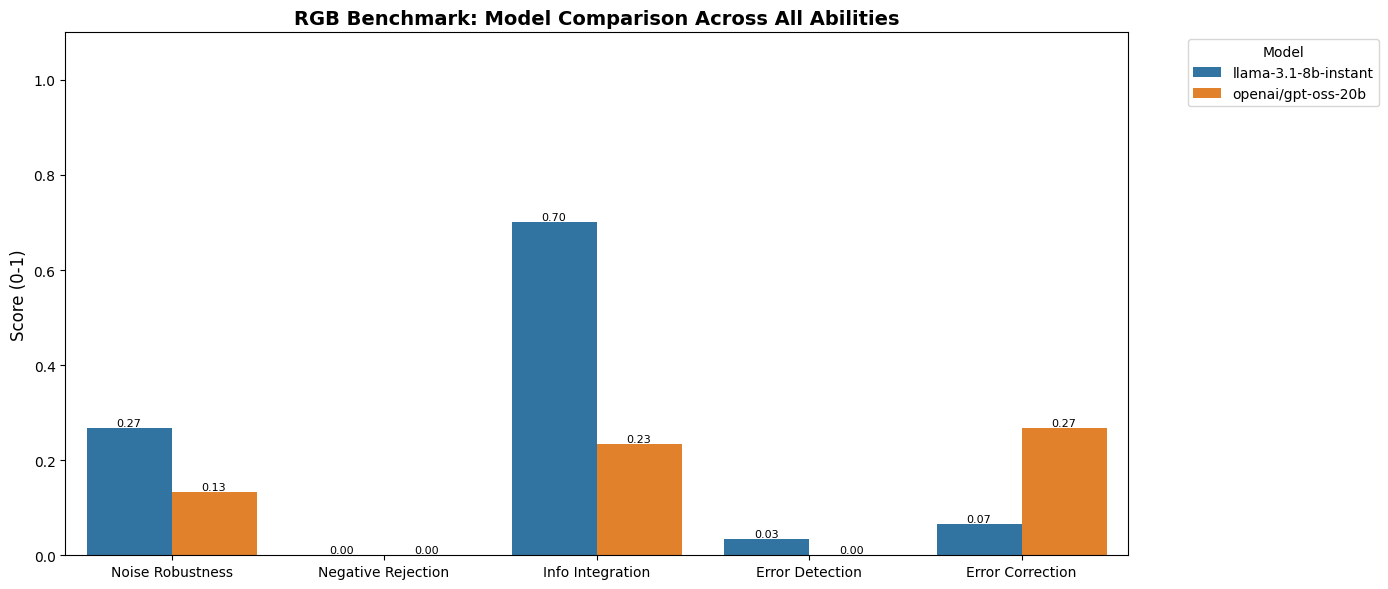

✅ Chart saved to rgb_comparison_chart.png


In [41]:
# Prepare data for plotting
plot_data = []
for row in summary_rows:
    model = row['Model']
    plot_data.append({'Model': model, 'Ability': 'Noise Robustness', 'Score': float(row['Noise Robustness (Accuracy)'])})
    plot_data.append({'Model': model, 'Ability': 'Negative Rejection', 'Score': float(row['Negative Rejection (Rate)'])})
    plot_data.append({'Model': model, 'Ability': 'Info Integration', 'Score': float(row['Info Integration (Accuracy)'])})
    plot_data.append({'Model': model, 'Ability': 'Error Detection', 'Score': float(row['Counterfactual Detection'])})
    plot_data.append({'Model': model, 'Ability': 'Error Correction', 'Score': float(row['Counterfactual Correction'])})

df_plot = pd.DataFrame(plot_data)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=df_plot, x='Ability', y='Score', hue='Model', ax=ax)
ax.set_title('RGB Benchmark: Model Comparison Across All Abilities', fontsize=14, fontweight='bold')
ax.set_ylabel('Score (0-1)', fontsize=12)
ax.set_xlabel('')
ax.set_ylim(0, 1.1)
ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8)

plt.tight_layout()
plt.savefig('rgb_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved to rgb_comparison_chart.png')

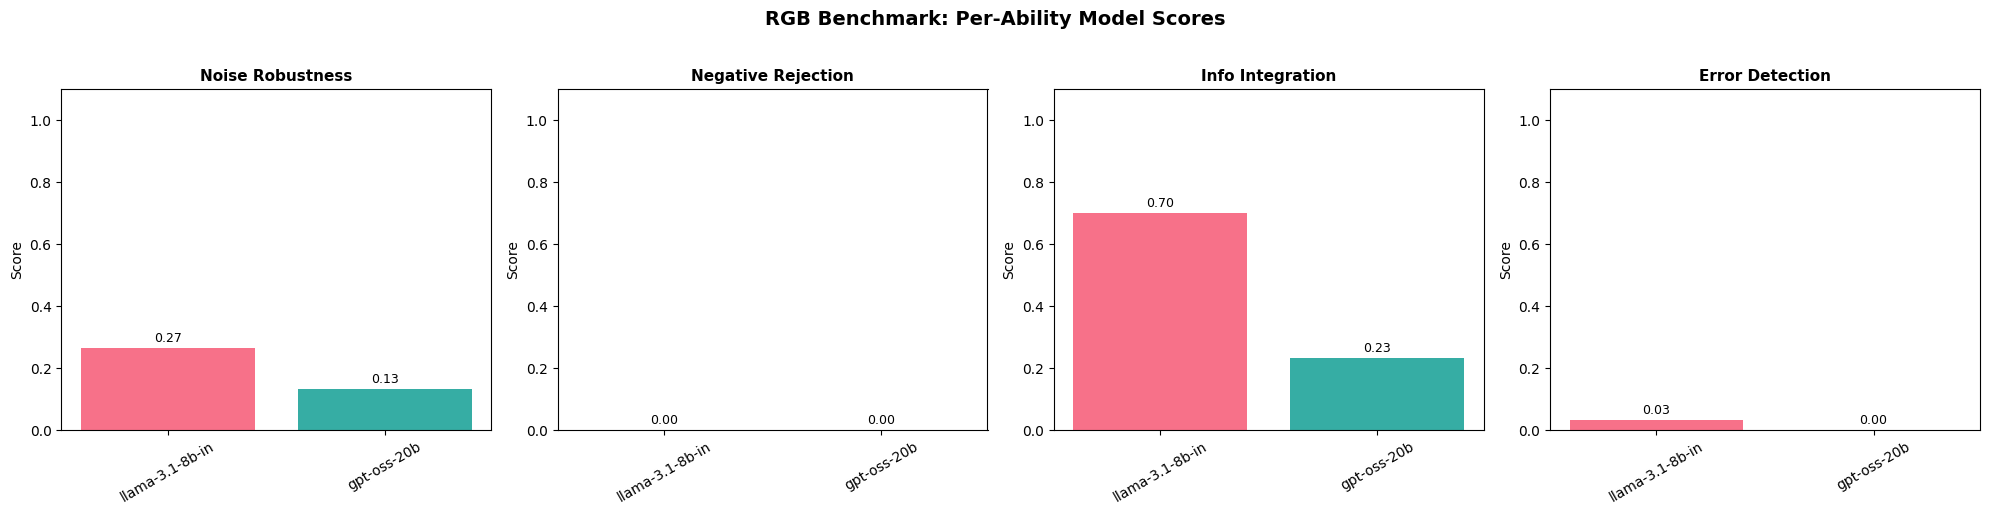

In [42]:
# Individual radar / subplot charts per ability
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

abilities = [
    ('Noise Robustness', 'Noise Robustness (Accuracy)'),
    ('Negative Rejection', 'Negative Rejection (Rate)'),
    ('Info Integration', 'Info Integration (Accuracy)'),
    ('Error Detection', 'Counterfactual Detection'),
]

colors = sns.color_palette('husl', len(MODELS_TO_EVALUATE))

for ax, (title, col) in zip(axes, abilities):
    scores = [float(row[col]) for row in summary_rows]
    models_short = [m.split('/')[-1][:15] for m in MODELS_TO_EVALUATE]
    bars = ax.bar(models_short, scores, color=colors)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{score:.2f}', ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('RGB Benchmark: Per-Ability Model Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rgb_per_ability_charts.png', dpi=150, bbox_inches='tight')
plt.show()

### 7c. Detailed Results: Sample-Level Analysis

In [43]:
# Show sample-level results for debugging and analysis
for model_name in MODELS_TO_EVALUATE:
    print(f'\n{"="*60}')
    print(f'MODEL: {model_name}')
    print(f'{"="*60}')

    # Noise Robustness samples
    nr = all_results[model_name]['noise_robustness']
    if nr:
        df_nr = pd.DataFrame(nr)
        print(f'\n--- Noise Robustness (first 5 incorrect) ---')
        incorrect = df_nr[df_nr['correct'] == 0].head(5)
        if len(incorrect) > 0:
            for _, row in incorrect.iterrows():
                print(f'  Q: {row["question"]}')
                print(f'  GT: {row["gt_answer"]}')
                print(f'  Response: {row["response"][:150]}')
                print()

    # Counterfactual samples
    cf = all_results[model_name]['counterfactual_robustness']
    if cf:
        df_cf = pd.DataFrame(cf)
        print(f'--- Counterfactual (first 3 where error NOT detected) ---')
        not_detected = df_cf[df_cf['error_detected'] == 0].head(3)
        if len(not_detected) > 0:
            for _, row in not_detected.iterrows():
                print(f'  Q: {row["question"]}')
                print(f'  Response: {row["response"][:200]}')
                print()


MODEL: llama-3.1-8b-instant

--- Noise Robustness (first 5 incorrect) ---
  Q: When is the premiere of 'Carole King & James Taylor: Just Call Out My Name'?
  GT: [['January 2 2022', 'Jan 2, 2022', 'Jan. 2, 2022', 'January 2, 2022', '2 January 2022', '2 Jan, 2022', '2 Jan., 2022', '2 January, 2022']]
  Response: I'm not provided with any documents. Please share the documents related to 'Carole King & James Taylor: Just Call Out My Name' so I can assist you wit

  Q: The genre of the drama "Good Sam" is what?
  GT: ['medical']
  Response: I don't see any documents provided. Please share the documents related to the drama "Good Sam" so I can assist you in answering the question.

  Q: Who won the 2022 Citrus Bowl?
  GT: ['Kentucky Wildcats']
  Response: I'm not provided with any documents. However, I can try to find the information about the 2022 Citrus Bowl.

The 2022 Citrus Bowl was played between I

  Q: What position did Jason Semore hold at Valdosta State before returning to Georgia

### 7d. Save All Results to JSON

In [44]:
# Save detailed results for later analysis
import json

output = {
    'config': {
        'models': MODELS_TO_EVALUATE,
        'max_samples': MAX_SAMPLES_PER_ABILITY,
        'delay': DELAY_BETWEEN_CALLS,
    },
    'summary': summary_rows,
    'detailed_results': {
        model: {
            ability: results
            for ability, results in model_results.items()
        }
        for model, model_results in all_results.items()
    }
}

with open('rgb_full_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

print('✅ Full results saved to rgb_full_results.json')
print('✅ Summary saved to rgb_results_summary.csv')
print('✅ Charts saved to rgb_comparison_chart.png and rgb_per_ability_charts.png')

✅ Full results saved to rgb_full_results.json
✅ Summary saved to rgb_results_summary.csv
✅ Charts saved to rgb_comparison_chart.png and rgb_per_ability_charts.png


## Step 8 (BONUS): Improve LLM Abilities Without Changing the Model
The RGB bonus asks: can you improve the 4 abilities using **prompt engineering only**?

Ideas to try:
1. **Chain-of-Thought (CoT):** Add "Think step by step" to prompts
2. **Few-Shot Examples:** Add 2-3 example Q&A pairs before the actual question
3. **Explicit Instructions:** More detailed instructions for rejection/detection
4. **Self-Consistency:** Sample multiple responses and take majority vote

Below is a template for CoT prompting on Noise Robustness:

In [47]:
# BONUS: Chain-of-Thought prompt for improved Noise Robustness
SYSTEM_PROMPT_COT = """You are a helpful assistant. Answer the question based on the given documents.
Think step by step:
1. First, identify which documents are relevant to the question.
2. Ignore any documents that are not related to the question.
3. Extract the specific answer from the relevant documents.
4. Provide a concise and direct final answer."""

# To evaluate: replace SYSTEM_PROMPT_ACCURACY with SYSTEM_PROMPT_COT
# in evaluate_noise_robustness() and compare results.

# Example: Run CoT on 10 samples of noise robustness with model 0
# Uncomment below to test:
print('Testing CoT prompt...')
cot_results, cot_accuracy = evaluate_noise_robustness(
    MODELS_TO_EVALUATE[0], data_en, max_samples=10, delay=2.0
)
print(f'CoT Accuracy: {cot_accuracy:.4f}')

Testing CoT prompt...

📊 Noise Robustness — llama-3.1-8b-instant — 10 samples


Noise Robustness: 100%|██████████| 10/10 [00:21<00:00,  2.17s/it]

  ✅ Accuracy: 0.3000 (3/10)
CoT Accuracy: 0.3000
